In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data7hafta.csv')
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# Gereksiz sütunları silme
df = df.drop(['id', 'Unnamed: 32'], axis=1)

# Hedef değişkeni sayısala çevirme
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

df.head(2)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


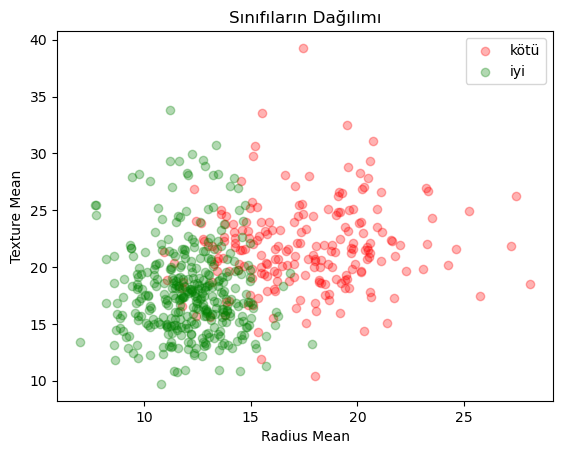

In [5]:
M = df[df.diagnosis == 1] #1 = Malignant (kötü huylu)
B = df[df.diagnosis == 0] #0 = Benign (iyi huylu)

plt.scatter(M.radius_mean, M.texture_mean, color='red', label='kötü', alpha=0.3)
plt.scatter(B.radius_mean, B.texture_mean, color='green', label='iyi', alpha=0.3)

plt.title("Sınıfıların Dağılımı")
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.legend()
plt.show()

In [6]:
# Bağımlı / Bağımsız değişkenleri belirleme
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [7]:
# Train / Test Bölme
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [8]:
# Scalling - SVM scale'e duyarlı olduğu için veriyi standartlaştırıyoruz.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# SVM modelini oluşturma
from sklearn.svm import SVC

model = SVC(kernel='rbf', C=1.0)

model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [10]:
# Tahmin ve değerlendirme
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[71  0]
 [ 2 41]]


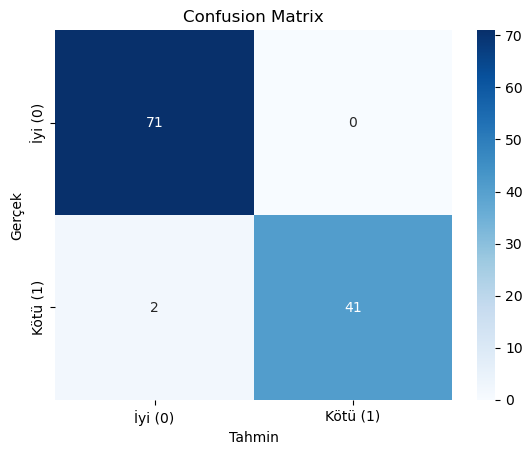

In [14]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d',
            cmap="Blues",
            xticklabels=["İyi (0)", "Kötü (1)"],
            yticklabels=["İyi (0)", "Kötü (1)"])

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.show()

In [15]:
from sklearn.metrics import accuracy_score

print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.9824561403508771


In [16]:
model1 = SVC(C=0.1)
model2 = SVC(C=100)

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

print("C=0.1 için doğruluk: ", model1.score(X_test, y_test))
print("C=100 için doğruluk: ", model2.score(X_test, y_test))






C=0.1 için doğruluk:  0.9473684210526315
C=100 için doğruluk:  0.9385964912280702


In [17]:
model1 = SVC(kernel='rbf', gamma=0.01)
model2 = SVC(kernel='rbf', gamma=10)

model1.fit(X_train, y_train)
model2.fit(X_train, y_train)

print("Gamma=0.01 için doğruluk: ", model1.score(X_test, y_test))
print("Gamma=10 için doğruluk: ", model2.score(X_test, y_test))

Gamma=0.01 için doğruluk:  0.9649122807017544
Gamma=10 için doğruluk:  0.6228070175438597
